<a href="https://colab.research.google.com/github/Hamerson-jhoel/Procesamiento-de-Lengaje-Natural/blob/main/Parcial1_PDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Nacional de Colombia sede Manizales

#Hamerson Jhoel Piarpuezan Piarpuezan
#cc. 1004531735

#Ejercicio 1: Análisis de Intensidad con Clases y NumPy
Contexto: Necesitas un módulo reutilizable para analizar la distribución de luz en imágenes médicas o satelitales sin depender de funciones de alto nivel para las estadísticas básicas.

- Instrucción: Crea una clase llamada ImageAnalyzer que reciba una matriz de NumPy (imagen en escala de grises). Debe incluir:

- Un método para normalizar la imagen al rango
.
- Un método que retorne la media y la desviación estándar ignorando los píxeles completamente negros (valor 0), ya que representan el fondo.
Pregunta para el examen:

¿Por qué es estadísticamente relevante filtrar los píxeles con valor 0 en imágenes donde el objeto de interés está rodeado de un fondo negro (ej: una radiografía)?

#Paso 1 Crear la estructura básica de la clase

    Primero solo creamos la clase y el constructor (__init__).

Aquí todavía no hacemos cálculos, solo guardamos la imagen.

### **class ImageAnalyzer:**
Aquí creamos una clase, que será nuestro módulo reutilizable.  
Es como crear una herramienta que luego podremos usar muchas veces.

---

### **def \_\_init\_\_(self, image):**
Este es el constructor.  
Aquí:
* **image** → es la imagen que pasas.
* **self.image** → es donde la guardamos dentro del objeto.

---

### **image.astype(np.float32)**
Esto convierte la imagen a tipo: **float32**

**¿Por qué?** Porque luego vamos a hacer divisiones (normalización), y si fueran enteros podría dar errores o truncamientos.

### **Paso 2 — Método para normalizar la imagen**

Ahora implementamos la lógica para
**Normalizar la imagen al rango [0, 1]**

Para lograr esto, aplicamos la siguiente fórmula:

$$I_{norm} = \frac{I - I_{min}}{I_{max} - I_{min}}$$

---
**¿Qué significa cada término?**
* $I$: Valor del píxel original.
* $I_{min}$: Valor mínimo de intensidad en la imagen.
* $I_{max}$: Valor máximo de intensidad en la imagen.
* $I_{norm}$: Nuevo valor del píxel escalado entre 0 y 1.

#Paso 3 — Método para media y desviación estándar sin ceros

Ahora hacemos el segundo método.

Este es muy importante conceptualmente.

Qué hace esta línea clave
    non_zero_pixels = self.image[self.image != 0]

Esto significa:

toma solo los valores que NO son 0

Luego:

    np.mean(non_zero_pixels)

Calcula:

media sin incluir fondo

Y:

    np.std(non_zero_pixels)

Calcula:

desviación estándar sin fondo

#Paso 4 — Probar la clase

Media sin ceros: 66.719284
Desviación estándar sin ceros: 71.428


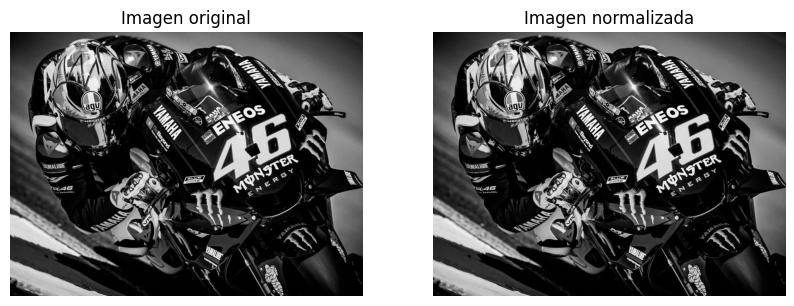

In [14]:
# ===============================
# EJERCICIO 1: Análisis de Intensidad con Clases y NumPy
# Todo en una sola celda
# ===============================

# -----------------------------------
# Importar librerías necesarias
# -----------------------------------

# NumPy: permite trabajar con matrices y operaciones numéricas
import numpy as np

# OpenCV: se usa para cargar la imagen en escala de grises
import cv2

# Matplotlib: se usa para visualizar imágenes
import matplotlib.pyplot as plt


# ===============================
# Definir la clase ImageAnalyzer
# ===============================

class ImageAnalyzer:

    # -----------------------------------
    # Constructor de la clase
    # -----------------------------------
    def __init__(self, image):
        """
        Recibe una imagen (matriz NumPy) y la convierte
        a tipo float32 para poder hacer cálculos con decimales.
        """
        self.image = image.astype(np.float32)


    # -----------------------------------
    # Método 1: Normalizar la imagen
    # -----------------------------------
    def normalize_image(self):

        """
        Normaliza la imagen al rango [0,1].

        Fórmula usada:
        (pixel - mínimo) / (máximo - mínimo)

        Esto permite que todos los valores
        queden entre 0 y 1.
        """

        # Obtener el valor mínimo de la imagen
        min_val = np.min(self.image)

        # Obtener el valor máximo de la imagen
        max_val = np.max(self.image)

        # Evitar división por cero si todos
        # los píxeles tienen el mismo valor
        if max_val - min_val == 0:
            return self.image

        # Aplicar normalización
        normalized = (self.image - min_val) / (max_val - min_val)

        return normalized


    # -----------------------------------
    # Método 2: Media y desviación estándar sin ceros
    # -----------------------------------
    def mean_std_without_zeros(self):

        """
        Calcula la media y desviación estándar
        ignorando los píxeles con valor 0.

        Los píxeles con valor 0 representan
        normalmente el fondo negro, que no
        pertenece al objeto de interés.
        """

        # Seleccionar solo píxeles distintos de 0
        non_zero_pixels = self.image[self.image != 0]

        # Calcular media
        mean = np.mean(non_zero_pixels)

        # Calcular desviación estándar
        std = np.std(non_zero_pixels)

        return mean, std


# ===============================
# Cargar imagen
# ===============================

# Cargar la imagen "rossi.jpg"
# en escala de grises (un solo canal)
img = cv2.imread("rossi.jpg", cv2.IMREAD_GRAYSCALE)


# ===============================
# Crear objeto de la clase
# ===============================

# Se crea una instancia de ImageAnalyzer
# pasando la imagen como parámetro
analyzer = ImageAnalyzer(img)


# ===============================
# Aplicar los métodos
# ===============================

# Normalizar la imagen al rango [0,1]
normalized_img = analyzer.normalize_image()

# Calcular media y desviación estándar
# ignorando los píxeles con valor 0
mean, std = analyzer.mean_std_without_zeros()

# Mostrar resultados en consola
print("Media sin ceros:", mean)
print("Desviación estándar sin ceros:", std)


# ===============================
# Visualización de resultados
# ===============================

# Crear figura
plt.figure(figsize=(10,4))

# -----------------------------------
# Mostrar imagen original
# -----------------------------------
plt.subplot(1,2,1)

plt.imshow(img, cmap='gray')

plt.title("Imagen original")

plt.axis("off")


# -----------------------------------
# Mostrar imagen normalizada
# -----------------------------------
plt.subplot(1,2,2)

plt.imshow(normalized_img, cmap='gray')

plt.title("Imagen normalizada")

plt.axis("off")


# Mostrar todo en pantalla
plt.show()

#¿Por qué es estadísticamente relevante filtrar los píxeles con valor 0?
Filtrar los píxeles con valor 0 es estadísticamente relevante porque estos representan el fondo negro y no contienen información útil sobre el objeto de interés.

Si se incluyen los píxeles con valor 0 en el cálculo de la media y la desviación estándar, estos valores reducen artificialmente la media y modifican la variabilidad de los datos, generando estadísticas que no representan correctamente las características reales del objeto.

En imágenes como radiografías, el fondo negro puede ocupar una gran parte de la imagen, por lo que incluir estos valores introduce un sesgo significativo en los cálculos. Ignorar los píxeles con valor 0 permite obtener estadísticas más precisas y representativas del área de interés.

Si se incluyen los píxeles con valor 0 en una radiografía, el histograma queda dominado por el fondo negro, lo que reduce artificialmente la media y altera la desviación estándar. Visualmente esto provoca un cálculo incorrecto del contraste y puede causar pérdida de detalle en los tejidos al aplicar normalización o segmentación.

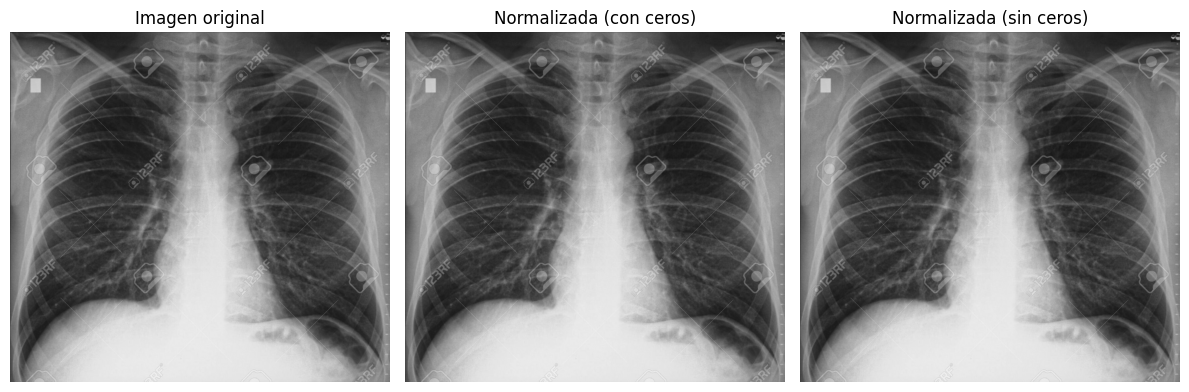

In [24]:
# ===============================
# Comparar normalización con y sin ceros
# ===============================

import numpy as np
import cv2
import matplotlib.pyplot as plt


# Cargar imagen
img = cv2.imread("pulmo.jpg", cv2.IMREAD_GRAYSCALE)

img = img.astype(np.float32)


# ===============================
# Normalización CON ceros
# ===============================

min_val = np.min(img)
max_val = np.max(img)

norm_with_zeros = (img - min_val) / (max_val - min_val)


# ===============================
# Normalización SIN ceros
# ===============================

non_zero_pixels = img[img != 0]

min_nz = np.min(non_zero_pixels)
max_nz = np.max(non_zero_pixels)

norm_without_zeros = img.copy()

# Normalizar solo usando rango sin ceros
norm_without_zeros = (img - min_nz) / (max_nz - min_nz)

# Ajustar valores negativos a 0
norm_without_zeros[norm_without_zeros < 0] = 0


# ===============================
# Mostrar imágenes
# ===============================

plt.figure(figsize=(12,4))

# Imagen original
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Imagen original")
plt.axis("off")


# Con ceros
plt.subplot(1,3,2)
plt.imshow(norm_with_zeros, cmap='gray')
plt.title("Normalizada (con ceros)")
plt.axis("off")


# Sin ceros
plt.subplot(1,3,3)
plt.imshow(norm_without_zeros, cmap='gray')
plt.title("Normalizada (sin ceros)")
plt.axis("off")


plt.tight_layout()
plt.show()

#Ejercicio 2: Diseño de Filtro Personalizado por Convolución
Contexto: Un sensor de visión en la línea de producción tiene un ruido vertical persistente. Necesitas aplicar un filtro que suavice la imagen pero solo en el eje horizontal para no perder definición en los bordes verticales.

Instrucción: Define un Kernel de
    
    que realice un promedio horizontal y aplícalo a una imagen usando scipy.ndimage.convolve.

Pregunta para el examen:

- Si aplicas un kernel donde la suma de todos sus elementos es mayor a 1, ¿qué efecto visual observarás en la imagen resultante?

### **¿Por qué horizontal y no vertical?**

Porque:
* **Ruido vertical** = columnas malas.
* **Promedio horizontal** = mezcla píxeles de izquierda–derecha.
* **Resultado:** Eso reduce las líneas verticales.

**Pero:**
**NO queremos suavizar verticalmente**, porque eso dañaría los **bordes verticales**.

---

### **Entonces lo que debes hacer es:**

1. **Crear un kernel 3×3** que haga promedio horizontal.
2. **Aplicarlo** a una imagen usando `scipy.ndimage.convolve`.
3. **Mostrar:** Imagen original e Imagen filtrada.

---

### **Paso clave — Diseñar el kernel correcto**

Te dicen:
* Kernel 3×3
* Promedio horizontal

Entonces el kernel debe promediar **izquierda – centro – derecha**, pero no arriba ni abajo.

**El kernel correcto es:**

```python
kernel = np.array([
    [0,   0,   0],
    [1/3, 1/3, 1/3],
    [0,   0,   0]
])

### **¿Qué hace este kernel?**

Solo usa:
- fila central

Eso significa:
- promedia horizontalmente

No afecta:
- verticalmente

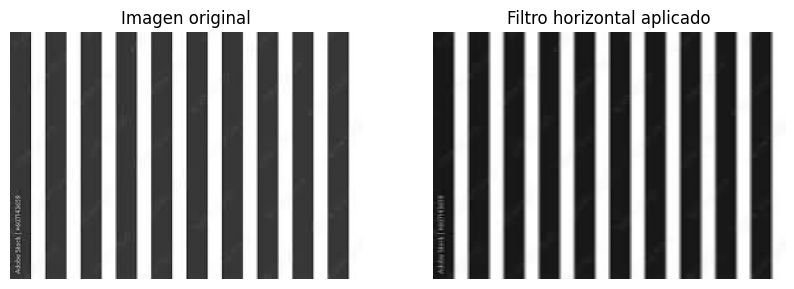

In [16]:
# Importar librerías necesarias

import numpy as np
# NumPy se usa para crear el kernel (matriz del filtro)

import cv2
# OpenCV se usa para cargar la imagen en escala de grises

import matplotlib.pyplot as plt
# Matplotlib se usa para mostrar las imágenes

from scipy.ndimage import convolve
# Importa la función convolve, que permite aplicar convolución
# entre la imagen y el kernel definido


# ===============================
# Cargar la imagen
# ===============================

img = cv2.imread("images.jpg", cv2.IMREAD_GRAYSCALE)
# Carga la imagen "rossi.jpg" en escala de grises
# Cada píxel tendrá valores entre 0 y 255


# ===============================
# Definir el kernel horizontal
# ===============================

kernel = np.array([
    [0, 0, 0],
    [1/3, 1/3, 1/3],
    [0, 0, 0]
])

# Este kernel es de tamaño 3x3
# Solo la fila central tiene valores distintos de 0
# Esto significa que el filtro actúa únicamente
# en dirección horizontal.

# Los valores 1/3 hacen un promedio horizontal
# entre el píxel izquierdo, central y derecho.

# Ejemplo conceptual:
# Nuevo píxel =
# (izquierda + centro + derecha) / 3

# Esto suaviza ruido vertical sin afectar
# demasiado los bordes verticales.


# ===============================
# Aplicar convolución
# ===============================

filtered_img = convolve(img, kernel)

# Se aplica el kernel sobre la imagen.
# Cada píxel se reemplaza por el resultado
# del promedio horizontal de sus vecinos.

# El resultado es una imagen suavizada
# horizontalmente.


# ===============================
# Mostrar la imagen suavizada
# ===============================

plt.figure(figsize=(10,4))
# Crea una figura para mostrar imágenes


# -----------------------------------
# Imagen original
# -----------------------------------

plt.subplot(1,2,1)
# Divide la figura en 1 fila y 2 columnas
# Posición 1 → imagen original

plt.imshow(img, cmap='gray')
# Muestra la imagen original

plt.title("Imagen original")
# Título de la imagen

plt.axis("off")
# Oculta los ejes


# -----------------------------------
# Imagen filtrada
# -----------------------------------

plt.subplot(1,2,2)
# Posición 2 → imagen filtrada

plt.imshow(filtered_img, cmap='gray')
# Muestra la imagen después del filtro

plt.title("Filtro horizontal aplicado")
# Título de la imagen filtrada

plt.axis("off")
# Oculta ejes


# Mostrar ambas imágenes
plt.show()

#Si aplicas un kernel donde la suma de todos sus elementos es mayor a 1, ¿qué efecto visual observarás en la imagen resultante?

Si la suma de los elementos del kernel es mayor que 1, la imagen resultante se verá más brillante.

Esto ocurre porque durante la convolución los valores de los píxeles se multiplican por los valores del kernel y se suman. Si la suma total del kernel es mayor que 1, el resultado amplifica la intensidad original de los píxeles, generando un aumento general en el brillo de la imagen.

En algunos casos extremos, esto puede provocar saturación, donde muchos píxeles alcanzan el valor máximo permitido.

Las líneas se ven más borrosas porque el filtro realiza un promedio entre píxeles vecinos en dirección horizontal. Esto suaviza las transiciones bruscas entre negro y blanco, generando valores intermedios (grises) que reducen la nitidez de los bordes.

Al aplicar el filtro horizontal sobre una imagen con líneas verticales, se observa que las líneas se vuelven más borrosas y pierden nitidez. Esto ocurre porque el filtro realiza un promedio horizontal que mezcla los valores de píxeles vecinos, reduciendo el contraste en los bordes verticales.

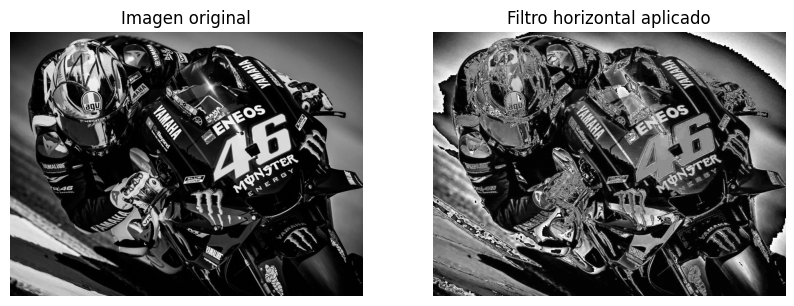

In [18]:
# Importar librerías necesarias

import numpy as np
# NumPy se usa para crear el kernel (matriz del filtro)

import cv2
# OpenCV se usa para cargar la imagen en escala de grises

import matplotlib.pyplot as plt
# Matplotlib se usa para mostrar las imágenes

from scipy.ndimage import convolve
# Importa la función convolve, que permite aplicar convolución
# entre la imagen y el kernel definido


# ===============================
# Cargar la imagen
# ===============================

img = cv2.imread("rossi.jpg", cv2.IMREAD_GRAYSCALE)
# Carga la imagen "rossi.jpg" en escala de grises
# Cada píxel tendrá valores entre 0 y 255


# ===============================
# Definir el kernel horizontal
# ===============================

kernel = np.array([
    [0, 0, 0],
    [1, 1, 1],
    [0, 0, 0]
])

# Este kernel es de tamaño 3x3
# Solo la fila central tiene valores distintos de 0
# Esto significa que el filtro actúa únicamente
# en dirección horizontal.

# Los valores 1/3 hacen un promedio horizontal
# entre el píxel izquierdo, central y derecho.

# Ejemplo conceptual:
# Nuevo píxel =
# (izquierda + centro + derecha) / 3

# Esto suaviza ruido vertical sin afectar
# demasiado los bordes verticales.


# ===============================
# Aplicar convolución
# ===============================

filtered_img = convolve(img, kernel)

# Se aplica el kernel sobre la imagen.
# Cada píxel se reemplaza por el resultado
# del promedio horizontal de sus vecinos.

# El resultado es una imagen suavizada
# horizontalmente.


# ===============================
# Mostrar la imagen suavizada
# ===============================

plt.figure(figsize=(10,4))
# Crea una figura para mostrar imágenes


# -----------------------------------
# Imagen original
# -----------------------------------

plt.subplot(1,2,1)
# Divide la figura en 1 fila y 2 columnas
# Posición 1 → imagen original

plt.imshow(img, cmap='gray')
# Muestra la imagen original

plt.title("Imagen original")
# Título de la imagen

plt.axis("off")
# Oculta los ejes


# -----------------------------------
# Imagen filtrada
# -----------------------------------

plt.subplot(1,2,2)
# Posición 2 → imagen filtrada

plt.imshow(filtered_img, cmap='gray')
# Muestra la imagen después del filtro

plt.title("Filtro horizontal aplicado")
# Título de la imagen filtrada

plt.axis("off")
# Oculta ejes


# Mostrar ambas imágenes
plt.show()

#Ejercicio 3: Limpieza de Imagen con Transformaciones Morfológicas
Contexto: Tras una umbralización (thresholding) en una imagen de satélite para detectar pozos petroleros, el resultado presenta "ruido de sal" (puntos blancos aislados) y pequeñas grietas en las estructuras detectadas.

Instrucción: Implementa una función que aplique una Apertura (Opening) seguida de un Cierre (Closing) utilizando un elemento estructurante de disco. Utiliza la librería
    
    skimage.morphology.

Pregunta para el examen:

¿Cuál es el riesgo de utilizar un elemento estructurante (kernel) demasiado grande al realizar una operación de Apertura en una imagen con detalles finos?

### 🔹 Explicación de la operación de Apertura (Opening)
La Apertura es una operación morfológica que consiste en aplicar primero una erosión seguida de una dilatación.  
Se representa como:  
**Opening = Erosión → Dilatación**

**¿Qué hace la erosión?** La erosión reduce el tamaño de los objetos blancos y elimina los píxeles pequeños que no están conectados a regiones mayores.  
Sirve para:
* Eliminar puntos blancos aislados (ruido de sal)
* Reducir pequeñas irregularidades
* Separar objetos que están débilmente conectados

**¿Qué hace la dilatación después?** La dilatación restaura parcialmente el tamaño original de los objetos después de la erosión, manteniendo eliminados los elementos pequeños que ya desaparecieron.

**Resultado de la Apertura:** Después de aplicar apertura:
* Se eliminan píxeles blancos pequeños
* Se mantiene la forma general de los objetos grandes
* Se limpia el ruido aislado  
Esta operación es especialmente útil cuando se desea eliminar ruido sin afectar significativamente las estructuras principales.

---

### 🔹 Explicación de la operación de Cierre (Closing)
El Cierre es otra operación morfológica que consiste en aplicar primero una dilatación seguida de una erosión.  
Se representa como:  
**Closing = Dilatación → Erosión**

**¿Qué hace la dilatación?** La dilatación aumenta el tamaño de los objetos blancos y permite que pequeñas grietas o espacios dentro de los objetos se cierren.  
Sirve para:
* Rellenar huecos pequeños
* Conectar regiones cercanas
* Cerrar grietas dentro de los objetos

**¿Qué hace la erosión después?** La erosión reduce nuevamente el tamaño del objeto, evitando que crezca demasiado, pero conservando los huecos que ya fueron rellenados.

**Resultado del Cierre:** Después de aplicar cierre:
* Se rellenan grietas pequeñas
* Se suavizan bordes internos
* Se fortalecen las estructuras detectadas

---

### 🔹 ¿Por qué se aplica Apertura seguida de Cierre?
El orden de las operaciones es importante.  
Primero se aplica **Apertura** para eliminar el ruido blanco aislado. Luego se aplica **Cierre** para rellenar pequeñas grietas dentro de los objetos que permanecieron.  

Este proceso permite obtener una imagen binaria más limpia, donde:
* El ruido es eliminado
* Las estructuras se mantienen completas
* Se mejora la calidad visual de la segmentación

---

### 🔹 Uso del elemento estructurante tipo disco
En este ejercicio se utiliza un elemento estructurante en forma de disco, generado mediante la función `disk()` de la librería `skimage.morphology`.  
Este tipo de elemento estructurante es útil porque:
* Tiene forma simétrica
* Permite trabajar de manera uniforme en todas las direcciones
* Es adecuado para objetos con formas redondeadas o irregulares  

El tamaño del disco (radio) determina qué tan agresiva será la operación morfológica.

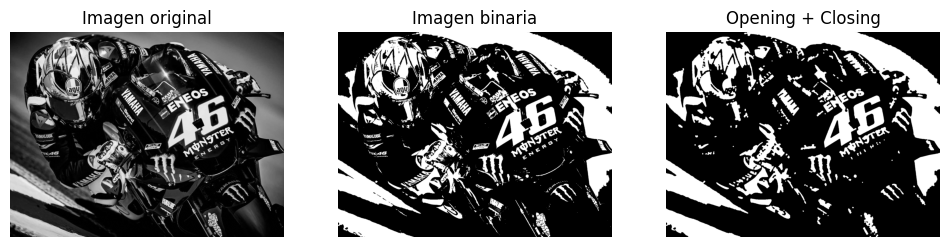

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.morphology import opening, closing, disk

# ===============================
# 1. Cargar imagen
# ===============================

img = io.imread("rossi.jpg")
# Carga la imagen desde el archivo "rossi.jpg"
# Puede ser RGB o escala de grises


# Convertir a escala de grises si es RGB
if len(img.shape) == 3:
    img_gray = rgb2gray(img)
    # Si la imagen tiene 3 canales (RGB),
    # se convierte a escala de grises
else:
    img_gray = img
    # Si ya es gris, se usa directamente


# ===============================
# 2. Umbralización (Threshold)
# ===============================

th = threshold_otsu(img_gray)
# Calcula automáticamente el valor de umbral
# usando el método de Otsu

img_bin = img_gray > th
# Convierte la imagen en binaria:
# píxeles mayores al umbral → blancos (True)
# píxeles menores → negros (False)


# ===============================
# 3. Función de limpieza morfológica
# ===============================

def limpiar_imagen(img_binaria, radio=3):

    # Crear elemento estructurante tipo disco
    selem = disk(radio)

    # disk(radio) genera una estructura circular
    # El radio controla el tamaño del filtro morfológico


    # Apertura (Opening)
    img_open = opening(img_binaria, selem)

    # Opening = erosión + dilatación
    # Sirve para eliminar:
    # - puntos blancos pequeños
    # - ruido tipo "sal"


    # Cierre (Closing)
    img_clean = closing(img_open, selem)

    # Closing = dilatación + erosión
    # Sirve para:
    # - cerrar pequeños huecos
    # - rellenar grietas pequeñas


    return img_clean
    # Retorna la imagen limpia


# Aplicar limpieza morfológica
img_limpia = limpiar_imagen(img_bin, radio=3)

# Se aplica la función definida antes
# usando un disco de radio 3


# ===============================
# 4. Visualización
# ===============================

fig, ax = plt.subplots(1,3, figsize=(12,4))
# Crear figura con 3 imágenes en fila


# Imagen original en gris
ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title("Imagen original")


# Imagen binaria después del umbral
ax[1].imshow(img_bin, cmap='gray')
ax[1].set_title("Imagen binaria")


# Imagen final después de Opening + Closing
ax[2].imshow(img_limpia, cmap='gray')
ax[2].set_title("Opening + Closing")


# Ocultar ejes
for a in ax:
    a.axis('off')


# Mostrar resultados
plt.show()

#¿Cuál es el riesgo de utilizar un elemento estructurante demasiado grande al realizar una Apertura en una imagen con detalles finos?
El riesgo de utilizar un elemento estructurante demasiado grande es que puede eliminar detalles finos importantes de la imagen. Durante la operación de apertura, los objetos pequeños o estructuras delgadas pueden desaparecer completamente si su tamaño es menor que el del elemento estructurante, causando pérdida de información relevante.

El uso de un elemento estructurante demasiado grande puede eliminar detalles finos importantes de la imagen, ya que la operación de apertura removerá estructuras pequeñas junto con el ruido, provocando pérdida de información relevante.

#Ejercicio 4: Segmentación de Múltiples Colores
Contexto: En el análisis de lesiones melanocíticas (piel), es crucial separar diferentes tonos cromáticos (marrones, rojizos, azulados) para identificar patrones atípicos.

Instrucción: Escribe un script que defina dos rangos de color en el espacio HSV para crear una máscara combinada (OR lógico). Segmentar tonos rosas y tonos verdes de la imagen https://raw.githubusercontent.com/UN-GCPDS/ProcesamientoDigitalImagenes/refs/heads/main/Parcial%201/Figuras/circles.png .

Pregunta para el examen:

¿Por qué es preferible realizar la segmentación por color en el espacio HSV (Hue, Saturation, Value) en lugar del espacio RGB convencional?

### **¿Qué es el espacio RGB?**
El espacio RGB representa colores usando tres componentes:
* **R** → Rojo
* **G** → Verde
* **B** → Azul

Cada color se obtiene combinando estos tres valores.  
**Ejemplo (Rojo puro):** `R = 255, G = 0, B = 0`

**Problema de RGB:** Los valores cambian mucho cuando cambia la iluminación, lo que dificulta segmentar colores de forma estable.

---

### **¿Qué es el espacio HSV?**
El espacio HSV representa colores de manera más cercana a cómo los percibe el ojo humano. Se compone de:

* **H — Hue (Tono):** Representa el color puro (Rojo, Verde, Azul, Rosa, etc.). Se mide en grados (0–179 en OpenCV).
* **S — Saturation (Saturación):** Representa la intensidad del color.
  * Baja saturación → color grisáceo.
  * Alta saturación → color intenso.
* **V — Value (Brillo):** Representa la luminosidad.
  * Bajo valor → oscuro.
  * Alto valor → brillante.

---

### **¿Por qué es mejor usar HSV que RGB?**

> Es preferible realizar la segmentación por color en el espacio HSV en lugar de RGB, porque **HSV separa la información de color (Hue) de la iluminación (Value)**.
>
> En el espacio RGB, los cambios de iluminación afectan simultáneamente los valores de R, G y B, dificultando la identificación consistente de colores. En cambio, en HSV el tono del color se encuentra en el canal Hue, lo que permite definir rangos de color más precisos y robustos ante variaciones de iluminación. Por esta razón, la segmentación basada en color es más estable y precisa en HSV que en RGB.

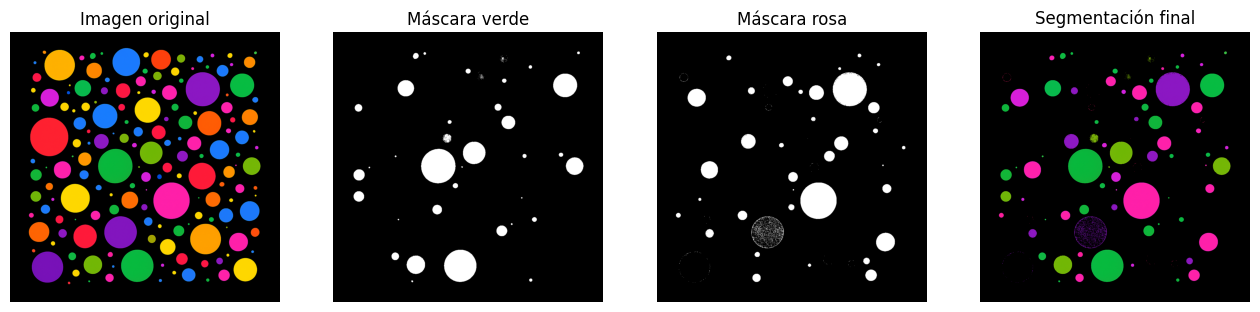

In [26]:
import numpy as np
# NumPy se usa para crear arreglos numéricos,
# en este caso los rangos de color HSV.

import cv2
# OpenCV se usa para cargar la imagen
# y trabajar con conversiones de color.

import matplotlib.pyplot as plt
# Matplotlib se usa para visualizar imágenes.


# ===============================
# 1. Cargar imagen
# ===============================

img = cv2.imread("circles.png")
# Carga la imagen desde el archivo.
# OpenCV la carga en formato BGR (no RGB).


# Convertir BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# OpenCV usa BGR por defecto.
# Matplotlib usa RGB.
# Por eso convertimos para que los colores se vean correctos.


# Convertir RGB → HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# Se convierte la imagen a espacio HSV,
# que separa el color real (Hue)
# del brillo y saturación.


# ===============================
# 2. Definir rangos HSV
# ===============================

# VERDE
lower_green = np.array([40, 50, 50])
# Límite inferior del color verde
# Hue ≈ 40

upper_green = np.array([80, 255, 255])
# Límite superior del color verde
# Hue ≈ 80


# ROSA (magenta)
lower_pink = np.array([140, 50, 50])
# Límite inferior del color rosa

upper_pink = np.array([170, 255, 255])
# Límite superior del color rosa


# ===============================
# 3. Crear máscaras
# ===============================

mask_green = cv2.inRange(img_hsv,
                         lower_green,
                         upper_green)

# Crea una máscara binaria:
# blanco → píxeles verdes
# negro → resto de colores


mask_pink = cv2.inRange(img_hsv,
                        lower_pink,
                        upper_pink)

# Crea otra máscara:
# blanco → píxeles rosados
# negro → resto


# ===============================
# 4. Combinar máscaras (OR)
# ===============================

mask_combined = cv2.bitwise_or(mask_green,
                               mask_pink)

# Une ambas máscaras:
# blanco → verde O rosa
# negro → otros colores


# ===============================
# 5. Aplicar máscara
# ===============================

result = cv2.bitwise_and(img_rgb,
                         img_rgb,
                         mask=mask_combined)

# Aplica la máscara a la imagen:
# solo se mantienen los píxeles
# verdes y rosados.
# El resto se vuelve negro.


# ===============================
# 6. Visualización
# ===============================

fig, ax = plt.subplots(1,4, figsize=(16,4))

# Crear una figura con 4 imágenes


ax[0].imshow(img_rgb)
ax[0].set_title("Imagen original")

# Muestra la imagen original
# con todos los colores.


ax[1].imshow(mask_green, cmap='gray')
ax[1].set_title("Máscara verde")

# Muestra solo los píxeles verdes.


ax[2].imshow(mask_pink, cmap='gray')
ax[2].set_title("Máscara rosa")

# Muestra solo los píxeles rosados.


ax[3].imshow(result)
ax[3].set_title("Segmentación final")

# Muestra la imagen final
# con verdes y rosas segmentados.


# Quitar ejes
for a in ax:
    a.axis('off')


# Mostrar resultado
plt.show()

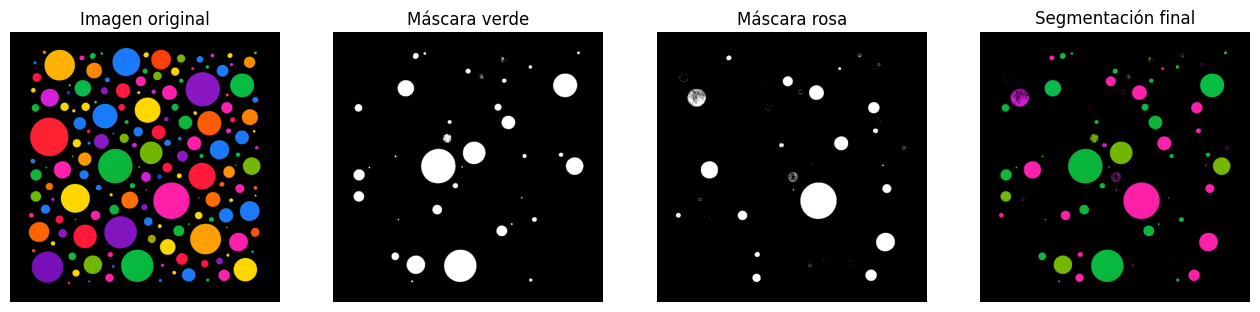

In [30]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ===============================
# 1. Cargar imagen
# ===============================

img = cv2.imread("circles.png")

# Convertir BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convertir RGB → HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# ===============================
# 2. Definir rangos HSV
# ===============================

# VERDE
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])

# ROSA (magenta)
lower_pink = np.array([150, 80, 80])
upper_pink = np.array([170, 255, 255])

# ===============================
# 3. Crear máscaras
# ===============================

mask_green = cv2.inRange(img_hsv,
                         lower_green,
                         upper_green)

mask_pink = cv2.inRange(img_hsv,
                        lower_pink,
                        upper_pink)

# ===============================
# 4. Combinar máscaras (OR)
# ===============================

mask_combined = cv2.bitwise_or(mask_green,
                               mask_pink)

# ===============================
# 5. Aplicar máscara
# ===============================

result = cv2.bitwise_and(img_rgb,
                         img_rgb,
                         mask=mask_combined)

# ===============================
# 6. Visualización
# ===============================

fig, ax = plt.subplots(1,4, figsize=(16,4))

ax[0].imshow(img_rgb)
ax[0].set_title("Imagen original")

ax[1].imshow(mask_green, cmap='gray')
ax[1].set_title("Máscara verde")

ax[2].imshow(mask_pink, cmap='gray')
ax[2].set_title("Máscara rosa")

ax[3].imshow(result)
ax[3].set_title("Segmentación final")

for a in ax:
    a.axis('off')

plt.show()

#¿Por qué es preferible realizar la segmentación por color en el espacio HSV en lugar de RGB?
Es preferible utilizar el espacio HSV para la segmentación por color porque separa la información del color (Hue) de la intensidad de brillo (Value). Esto permite definir rangos de color más estables y menos sensibles a cambios de iluminación. En el espacio RGB, el color depende simultáneamente de los tres canales, lo que dificulta la segmentación precisa cuando varía la iluminación o el brillo.

#Ejercicio 5: Detección de Bordes y Umbralización Adaptativa
Contexto: En imágenes de microscopía o fotografías capturadas en campo, la iluminación rara vez es uniforme. Un umbral global (Global Threshold) fallaría al segmentar objetos en zonas de sombra.

Instrucción: Implementa un script que:

Aplique un Umbral Adaptativo de Gauss para binarizar una imagen con iluminación irregular.
Utilice el algoritmo de Canny para extraer los bordes de la imagen original.
Pregunta para el examen:

El algoritmo de Canny utiliza un paso llamado "Supresión de No-Máximos". ¿Cuál es el objetivo de este paso y qué le sucedería a los bordes si se omitiera?

# Detección de Bordes y Umbralización Adaptativa

### **¿Qué pide  el ejercicio?**
Te pide hacer dos cosas distintas sobre una imagen:

1.  **Aplicar un umbral adaptativo Gaussiano:** Para convertir la imagen en binaria, incluso si la iluminación no es uniforme.
2.  **Aplicar el algoritmo de Canny:** Para detectar bordes en la imagen original.

**Pregunta teórica clave:**
> ¿Cuál es el objetivo de la supresión de no-máximos en Canny y qué pasaría si no se usara?

---

### **¿Qué significa el contexto?**
El enunciado dice: *"la iluminación rara vez es uniforme"*. Esto implica que algunas zonas están claras y otras oscuras.

* **Umbral global:** Falla porque un solo valor no sirve para toda la imagen.
* **Umbral adaptativo:** Funciona mejor porque calcula un umbral distinto en cada región.

---

### **Parte 1 — Qué es el Umbral Adaptativo Gaussiano**
Convierte la imagen en **Blanco (objeto)** y **Negro (fondo)** usando un umbral local.

* En el método Gaussiano, el umbral se calcula usando un promedio ponderado Gaussiano de los píxeles vecinos.
* Esto permite segmentar objetos incluso si hay **sombras** o **iluminación irregular**.

---

### **Parte 2 — Qué es el algoritmo de Canny**
Es uno de los mejores detectores de bordes. Encuentra contornos, límites y bordes finos.

**¿Qué deberías ver en las imágenes?**
* **Imagen 1 (Original):** Tu imagen normal en escala de grises.
* **Imagen 2 (Umbral adaptativo):** Se verá blanco (objetos) y negro (fondo). Debería funcionar bien incluso con sombras.
* **Imagen 3 (Canny):** Se verán líneas delgadas y contornos finos (solo los límites importantes).

---

### **⚙️ Parámetros importantes (para entender el código)**

**`adaptiveThreshold`**
* **11:** Tamaño del vecindario (si aumenta, suaviza más).
* **2:** Ajuste del umbral (si aumenta, la imagen queda más oscura).

**`Canny`**
* **100:** Umbral bajo.
* **200:** Umbral alto.
* *Si subes estos valores:* Detecta menos bordes.
* *Si los bajas:* Detecta más ruido.

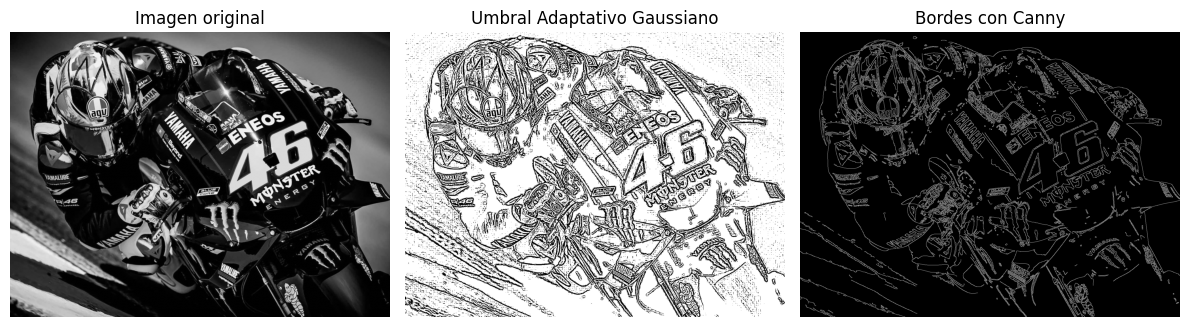

In [31]:
import cv2
# OpenCV se usa para cargar la imagen
# y aplicar los algoritmos de procesamiento.

import matplotlib.pyplot as plt
# Matplotlib se usa para visualizar las imágenes.


# =========================
# 1. Cargar imagen
# =========================

# Usa tu imagen (por ejemplo rossi.jpg)
img = cv2.imread("rossi.jpg", cv2.IMREAD_GRAYSCALE)

# Carga la imagen en escala de grises.
# Cada píxel tendrá valores entre 0 (negro)
# y 255 (blanco).


# =========================
# 2. Umbral Adaptativo Gaussiano
# =========================

adaptive_thresh = cv2.adaptiveThreshold(
    img,
    255,                         # valor máximo
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,                          # tamaño del vecindario
    2                            # constante
)

# adaptiveThreshold convierte la imagen
# en binaria usando un umbral LOCAL.

# Parámetros importantes:

# img → imagen de entrada

# 255 → valor que se asigna a los píxeles
# que superan el umbral (blanco)

# ADAPTIVE_THRESH_GAUSSIAN_C →
# calcula el umbral usando un promedio
# ponderado Gaussiano de los vecinos.

# THRESH_BINARY →
# píxeles mayores al umbral → blanco
# menores → negro

# 11 →
# tamaño del vecindario (11x11 píxeles)

# 2 →
# constante que se resta al promedio.
# Ajusta qué tan estricta es la binarización.


# =========================
# 3. Detección de bordes (Canny)
# =========================

edges = cv2.Canny(
    img,
    100,   # umbral bajo
    200    # umbral alto
)

# Canny detecta bordes en la imagen.

# 100 → umbral inferior
# detecta bordes débiles.

# 200 → umbral superior
# detecta bordes fuertes.

# El algoritmo mantiene bordes fuertes
# y algunos débiles conectados a ellos.


# =========================
# 4. Visualización
# =========================

plt.figure(figsize=(12,4))
# Crear figura donde se mostrarán
# tres imágenes en fila.


plt.subplot(1,3,1)
# 1 fila, 3 columnas, posición 1

plt.imshow(img, cmap="gray")
# Mostrar imagen original.

plt.title("Imagen original")

plt.axis("off")
# Ocultar ejes.


plt.subplot(1,3,2)
# Posición 2

plt.imshow(adaptive_thresh, cmap="gray")
# Mostrar imagen binaria adaptativa.

plt.title("Umbral Adaptativo Gaussiano")

plt.axis("off")


plt.subplot(1,3,3)
# Posición 3

plt.imshow(edges, cmap="gray")
# Mostrar bordes detectados con Canny.

plt.title("Bordes con Canny")

plt.axis("off")


plt.tight_layout()
# Ajusta espacios entre imágenes.

plt.show()
# Mostrar figura final.

#El algoritmo de Canny utiliza un paso llamado "Supresión de No-Máximos".
¿Cuál es el objetivo de este paso y qué sucedería si se omitiera?


La supresión de no-máximos en el algoritmo de Canny tiene como objetivo adelgazar los bordes detectados, conservando únicamente los píxeles que representan el máximo local en la dirección del gradiente.

Este proceso elimina píxeles que no corresponden al punto más fuerte del borde, permitiendo obtener contornos finos y bien definidos.

Si se omitiera la supresión de no-máximos, los bordes detectados aparecerían gruesos, difusos y menos precisos, ya que múltiples píxeles cercanos serían considerados parte del mismo borde.

En la imagen del motociclista, la supresión de no-máximos permite que los bordes del casco, número 46 y estructura de la moto se vean como líneas delgadas y bien definidas. Este paso elimina píxeles que no corresponden al máximo local del gradiente. Si se omitiera, los bordes aparecerían gruesos, duplicados y menos precisos.